# Inteligencia Computacional — Guía de trabajos prácticos 1

## Perceptrón simple

UNL · FICH · Departamento de Informática · Ingeniería Informática

---

## El modelo

El perceptrón simple es un modelo computacional muy simplificado de una neurona biológica.
Cada entrada $x_i$ llega a la neurona a través de una conexión con un **peso sináptico**
$w_i$, que representa cuánto contribuye esa entrada a la activación: un peso positivo
grande equivale a una sinapsis excitatoria fuerte, un peso negativo a una conexión
inhibitoria, y un peso nulo a una desconexión.


<svg width="660" height="300" viewBox="0 0 660 300" xmlns="http://www.w3.org/2000/svg">
  <style>
    .ent { fill: #2a78d6; }
    .ses { fill: #eb6834; }
    .cue { fill: none; stroke: #0b0b0b; stroke-width: 2; }
    .con { stroke: #898781; stroke-width: 1.6; fill: none; }
    .tx  { font-family: system-ui, sans-serif; font-size: 15px; fill: #0b0b0b; }
    .tp  { font-family: system-ui, sans-serif; font-size: 13px; fill: #52514e; }
    .tt  { font-family: system-ui, sans-serif; font-size: 12px; fill: #898781; }
  </style>

  <circle class="ent" cx="45" cy="70"  r="17"/>
  <circle class="ent" cx="45" cy="140" r="17"/>
  <circle class="ent" cx="45" cy="230" r="17"/>
  <text class="tx" x="36" y="76"  fill="#ffffff">x1</text>
  <text class="tx" x="36" y="146" fill="#ffffff">x2</text>
  <text class="tx" x="36" y="236" fill="#ffffff">xn</text>
  <text class="tt" x="42" y="192">.</text>
  <text class="tt" x="42" y="185">.</text>

  <line class="con" x1="62" y1="70"  x2="243" y2="145"/>
  <line class="con" x1="62" y1="140" x2="243" y2="150"/>
  <line class="con" x1="62" y1="230" x2="243" y2="160"/>
  <text class="tp" x="120" y="90">w1</text>
  <text class="tp" x="120" y="139">w2</text>
  <text class="tp" x="120" y="212">wn</text>

  <circle class="ses" cx="150" cy="35" r="16"/>
  <text class="tx" x="139" y="41" fill="#ffffff">-1</text>
  <line class="con" x1="166" y1="35" x2="243" y2="140"/>
  <text class="tp" x="198" y="62">&#952;</text>

  <circle class="cue" cx="270" cy="150" r="30"/>
  <text class="tx" x="259" y="159" font-size="21">&#931;</text>
  <text class="tt" x="222" y="207">suma ponderada</text>

  <line class="con" x1="300" y1="150" x2="378" y2="150"/>
  <text class="tp" x="314" y="140">neta</text>

  <rect class="cue" x="380" y="112" width="76" height="76" rx="6"/>
  <line x1="392" y1="150" x2="418" y2="150" stroke="#2a78d6" stroke-width="2.5"/>
  <line x1="418" y1="150" x2="418" y2="126" stroke="#2a78d6" stroke-width="2.5"/>
  <line x1="418" y1="126" x2="444" y2="126" stroke="#2a78d6" stroke-width="2.5"/>
  <text class="tt" x="382" y="207">activaci&#243;n</text>

  <line class="con" x1="458" y1="150" x2="534" y2="150"/>
  <polygon points="534,145 547,150 534,155" fill="#898781"/>
  <text class="tx" x="556" y="157">y = &#177;1</text>

  <text class="tp" x="212" y="268">neta = &#931; wi&#183;xi &#8722; &#952;</text>
  <text class="tp" x="382" y="268">y = signo(neta)</text>
</svg>


La neurona realiza dos operaciones. Primero calcula la **suma ponderada** de sus entradas y
le resta el **umbral** $\theta$, obteniendo la activación lineal o entrada neta:

$$\text{neta} \;=\; \sum_{i=1}^{n} w_i x_i \;-\; \theta$$

Luego aplica la **función de activación**, que en este trabajo es la función signo y
reproduce el comportamiento de *todo o nada* de la neurona biológica: si la excitación
acumulada supera el umbral, la neurona dispara.

$$y \;=\; \operatorname{signo}(\text{neta}) \;=\;
\begin{cases}
+1 & \text{si } \text{neta} \geq 0 \\[3pt]
-1 & \text{si } \text{neta} < 0
\end{cases}$$

La suma ponderada puede escribirse como el **producto interno** entre el vector de pesos y
el vector de entradas, lo que además explica por qué la frontera de decisión resulta ser un
objeto lineal:

$$\text{neta} \;=\; \mathbf{w} \cdot \mathbf{x} \;-\; \theta$$

Una forma habitual de compactar la notación consiste en incorporar el umbral a la
sumatoria, tratándolo como un peso $w_0 = \theta$ asociado a una entrada ficticia constante
$x_0 = -1$, de modo que todo queda expresado como una única sumatoria desde $i = 0$. En esta
implementación se optó por mantener `umbral` como atributo separado de `pesos`, para que el
rol de cada parámetro quede explícito en el código.

### La regla de aprendizaje

Los pesos no se programan: se aprenden a partir de ejemplos. Se inicializan al azar con
valores pequeños y se corrigen ante cada patrón presentado, en proporción al error cometido
y a la **tasa de aprendizaje** $\eta$:

$$w_i \leftarrow w_i + \eta \, (d - y) \, x_i
\qquad\qquad
\theta \leftarrow \theta - \eta \, (d - y)$$

donde $d$ es la salida deseada e $y$ la salida obtenida. Ambas expresiones difieren en el
signo porque el umbral equivale a un peso sobre una entrada constante $-1$.

Esta única fórmula contempla los dos casos posibles:

- Si la neurona **responde correctamente**, $d = y$, el error $(d - y)$ se anula y nada se
  modifica. Es el **principio de mínima perturbación**: si algo funciona, no se toca.
- Si la neurona **se equivoca**, el error vale $\pm 2$ y los pesos se desplazan en la
  dirección que corrige esa salida, con una magnitud proporcional a $\eta$.

### La frontera de decisión

La neurona cambia de respuesta exactamente donde la entrada neta se anula. Para dos
entradas, esa condición define una **recta** en el plano:

$$w_1 x_1 + w_2 x_2 - \theta = 0
\qquad \Longrightarrow \qquad
x_2 = \frac{\theta - w_1 x_1}{w_2}$$

Los pesos determinan su **pendiente** y el umbral su **ordenada al origen**. Sin umbral la
recta estaría obligada a pasar por el origen, lo que impediría resolver incluso problemas
tan elementales como el OR; de allí la importancia de que cada neurona disponga de su propio
sesgo.

### Organización del código

La implementación vive en el paquete `src/`, de modo que este notebook se limita a ejecutar
los experimentos y discutir los resultados:

| archivo | contenido |
|---|---|
| `src/perceptron.py` | clase `Perceptron`: pesos, umbral, activación, regla de aprendizaje, entrenamiento y prueba |
| `src/data_loader.py` | lectura de los archivos de patrones separados por comas |
| `src/graficos.py` | rutinas de graficación |

In [1]:
from pathlib import Path

from src.data_loader import cargar_patrones
from src.graficos import (
    graficar_comparacion_dispersiones,
    graficar_entrenamiento,
    graficar_errores_por_epoca,
)
from src.perceptron import Perceptron

DIRECTORIO_DATASET = Path("Dataset")

tasa_aprendizaje = 0.1
maximo_epocas = 100
criterio_de_corte = "cero_errores"
semilla = 42

---

## Ejercicio 1

> Implemente rutinas que permitan el entrenamiento y prueba de un perceptrón simple con una
> cantidad variable de entradas. Se deben tener en cuenta las siguientes capacidades:
>
> - lectura de los patrones de entrenamiento (entradas y salidas) desde un archivo en
>   formato texto separado por comas,
> - selección del criterio de finalización del entrenamiento y el número máximo de épocas,
> - selección de la tasa de aprendizaje,
> - prueba del perceptrón entrenado mediante archivos de texto con el mismo formato separado
>   por comas.
>
> Una vez obtenido dicho programa, pruébelo en la resolución del problema OR, utilizando los
> archivos de patrones `OR_trn.csv` y `OR_tst.csv` para el entrenamiento y la prueba,
> respectivamente. Los patrones que se proveen en estos archivos fueron generados a partir de
> los puntos (1,1), (1,-1), (-1,1) y (-1,-1) con pequeñas desviaciones aleatorias (< 5 %) en
> torno a éstos. Recuerde que para que la prueba tenga validez se deben utilizar patrones
> nunca presentados en el entrenamiento, para ésto se dispone de dos archivos de datos
> diferentes.

### Qué se implementó

Las cuatro capacidades pedidas se resolvieron así:

| capacidad | dónde |
|---|---|
| lectura de patrones separados por comas | `cargar_patrones()` separa las columnas de entrada de la última columna, que es la salida deseada |
| criterio de finalización | parámetro `criterio_de_corte` de `entrenar()`: `"cero_errores"` corta apenas una época termina sin errores; cualquier otro valor agota el máximo |
| número máximo de épocas | parámetro `maximo_epocas` de `entrenar()` |
| tasa de aprendizaje | parámetro `tasa_aprendizaje` al construir el `Perceptron` |
| prueba con archivo aparte | `probar()` recorre los patrones aplicando `predecir()` sin modificar los pesos |

**Cantidad variable de entradas.** No está fijada en ninguna parte del código: se deduce de
la forma de los datos mediante `entradas.shape[1]`, y el vector `pesos` se dimensiona en
consecuencia, por lo que la misma implementación sirve para dos entradas o para cincuenta.

**Patrón y época.** Un *patrón* es un ejemplo de entrenamiento, es decir una fila del
archivo, con sus entradas y su salida deseada. Una *época* es una pasada completa por todos
los patrones del archivo, presentándolos de a uno y aplicando la regla de aprendizaje en
cada caso. Se repiten épocas porque cada corrección atiende a un solo patrón por vez y puede
desajustar patrones ya aprendidos, de modo que hace falta recorrer el conjunto varias veces
hasta que los pesos se estabilicen.

In [2]:
entradas_or, salidas_deseadas_or = cargar_patrones(DIRECTORIO_DATASET / "OR_trn.csv")
entradas_or_prueba, salidas_deseadas_or_prueba = cargar_patrones(DIRECTORIO_DATASET / "OR_tst.csv")

perceptron_or = Perceptron(
    cantidad_entradas=entradas_or.shape[1],
    tasa_aprendizaje=tasa_aprendizaje,
    semilla=semilla,
)

errores_por_epoca_or, historial_pesos_or = perceptron_or.entrenar(
    entradas_or,
    salidas_deseadas_or,
    maximo_epocas=maximo_epocas,
    criterio_de_corte=criterio_de_corte,
)

porcentaje_aciertos_or, cantidad_errores_or = perceptron_or.probar(
    entradas_or_prueba, salidas_deseadas_or_prueba
)

print(f"Patrones de entrenamiento : {len(salidas_deseadas_or)}")
print(f"Patrones de prueba        : {len(salidas_deseadas_or_prueba)}")
print(f"Épocas utilizadas         : {len(errores_por_epoca_or)}")
print(f"Errores por época         : {errores_por_epoca_or}")
print(f"Pesos finales             : {perceptron_or.pesos}")
print(f"Umbral final              : {perceptron_or.umbral:.4f}")
print(f"Aciertos en prueba        : {porcentaje_aciertos_or:.2f}% "
      f"({cantidad_errores_or} errores sobre {len(salidas_deseadas_or_prueba)})")

Patrones de entrenamiento : 2000
Patrones de prueba        : 200
Épocas utilizadas         : 2
Errores por época         : [6, 0]
Pesos finales             : [0.27711205 0.33775844]
Umbral final              : -0.4414
Aciertos en prueba        : 100.00% (0 errores sobre 200)


### Análisis

El perceptrón resuelve el OR sin dificultad: **converge en 2 épocas y clasifica
correctamente el 100 % de los patrones de prueba**, que nunca vio durante el entrenamiento.
En la primera pasada se equivoca en apenas 6 de los 2000 patrones y en la segunda ya no
comete ningún error, por lo que el criterio `cero_errores` corta el entrenamiento mucho
antes del máximo de 100 épocas.

El resultado es el esperado: los cuatro grupos de patrones están muy concentrados en torno a
sus vértices, con desviaciones menores al 5 %, y la clase $-1$ ocupa un único vértice. El
problema es **linealmente separable** y basta una recta para resolverlo. Que el acierto sea
del 100 % sobre un archivo de prueba independiente muestra además que la neurona no memorizó
los ejemplos sino que **generalizó** la regla subyacente.

Respecto de los parámetros configurables cabe hacer dos observaciones.

**La tasa de aprendizaje resultó indiferente en este problema.** Se ensayaron valores entre
0,001 y 1,0, cruzados con distintas inicializaciones aleatorias, y en todos los casos el
entrenamiento convergió en las mismas 2 épocas con 100 % de aciertos. La explicación está en
la función de activación: la salida es $\operatorname{signo}(w_1x_1 + w_2x_2 - \theta)$ y el
signo es **invariante a escala**, de modo que multiplicar $w_1$, $w_2$ y $\theta$ por
cualquier constante positiva deja la recta de separación exactamente en el mismo lugar. La
tasa de aprendizaje regula la magnitud de los pesos, no la posición de la frontera, por lo
que en un problema separable y con márgenes amplios su efecto es despreciable.

**El máximo de épocas tampoco es limitante aquí**, porque el criterio de corte por cero
errores se activa mucho antes. Su verdadera utilidad aparece en el Ejercicio 2, donde el
entrenamiento nunca converge y el máximo de épocas pasa a ser el único criterio de corte
efectivo.

---

## Ejercicio 2

> Implemente una rutina de graficación que permita visualizar, para el caso de dos entradas,
> los patrones utilizados y la recta de separación que se va ajustando durante el
> entrenamiento del perceptrón simple. Utilice dicha rutina para visualizar el entrenamiento
> en los problemas OR y XOR (utilizando los archivos de datos `OR_trn.csv` y `XOR_trn.csv`).

### Qué se implementó

`graficar_entrenamiento()` dibuja los patrones coloreados según su clase y superpone la
recta de separación correspondiente a cada estado de los pesos guardado durante el
entrenamiento. La recta se obtiene despejando $x_2$ de la condición de entrada neta nula:

$$w_1 x_1 + w_2 x_2 - \theta = 0
\qquad \Longrightarrow \qquad
x_2 = \frac{\theta - w_1 x_1}{w_2}$$

Para poder graficar la evolución, `entrenar()` devuelve un `historial_pesos` con una copia
de $(\mathbf{w}, \theta)$ al término de cada época, más el estado inicial aleatorio previo al
entrenamiento. En los gráficos las posiciones intermedias aparecen en gris —más tenues
cuanto más antiguas— y la recta final en negro.

### OR

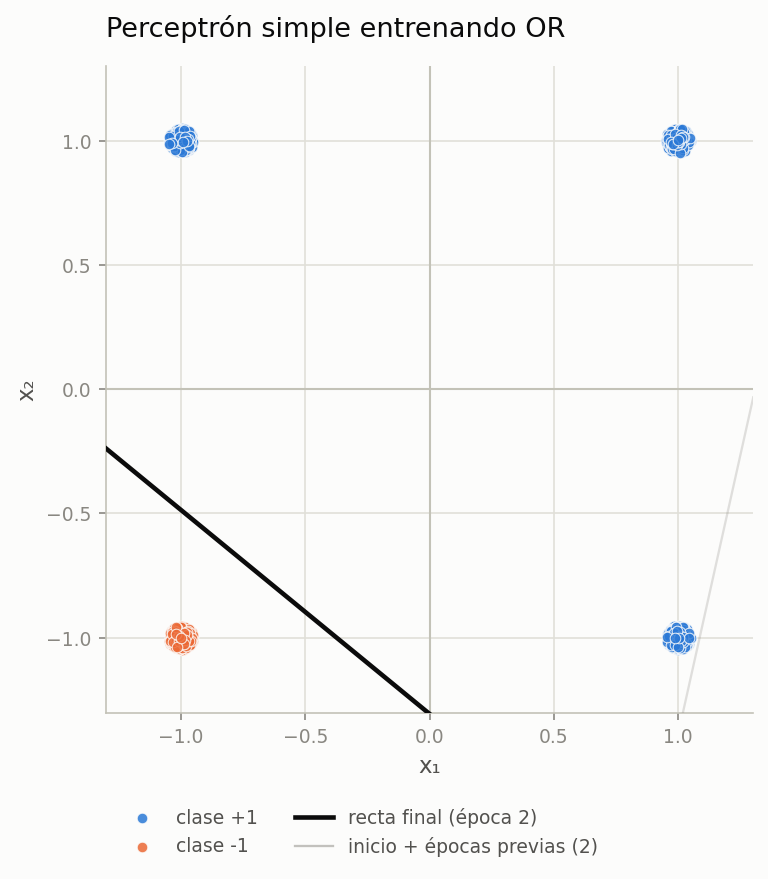

In [3]:
graficar_entrenamiento(
    entradas_or,
    salidas_deseadas_or,
    historial_pesos_or,
    titulo="Perceptrón simple entrenando OR",
);

### XOR

In [4]:
entradas_xor, salidas_deseadas_xor = cargar_patrones(DIRECTORIO_DATASET / "XOR_trn.csv")
entradas_xor_prueba, salidas_deseadas_xor_prueba = cargar_patrones(DIRECTORIO_DATASET / "XOR_tst.csv")

perceptron_xor = Perceptron(
    cantidad_entradas=entradas_xor.shape[1],
    tasa_aprendizaje=tasa_aprendizaje,
    semilla=semilla,
)

errores_por_epoca_xor, historial_pesos_xor = perceptron_xor.entrenar(
    entradas_xor,
    salidas_deseadas_xor,
    maximo_epocas=20,
    criterio_de_corte=criterio_de_corte,
)

porcentaje_aciertos_xor, cantidad_errores_xor = perceptron_xor.probar(
    entradas_xor_prueba, salidas_deseadas_xor_prueba
)

print(f"Épocas utilizadas   : {len(errores_por_epoca_xor)}")
print(f"Errores por época   : {errores_por_epoca_xor}")
print(f"Pesos finales       : {perceptron_xor.pesos}")
print(f"Umbral final        : {perceptron_xor.umbral:.4f}")
print(f"Aciertos en prueba  : {porcentaje_aciertos_xor:.2f}% "
      f"({cantidad_errores_xor} errores sobre {len(salidas_deseadas_xor_prueba)})")

Épocas utilizadas   : 20
Errores por época   : [878, 834, 836, 842, 873, 810, 837, 849, 870, 814, 844, 866, 872, 920, 873, 865, 778, 837, 813, 845]
Pesos finales       : [-0.00304395  0.13482444]
Umbral final        : -0.0414
Aciertos en prueba  : 51.00% (98 errores sobre 200)


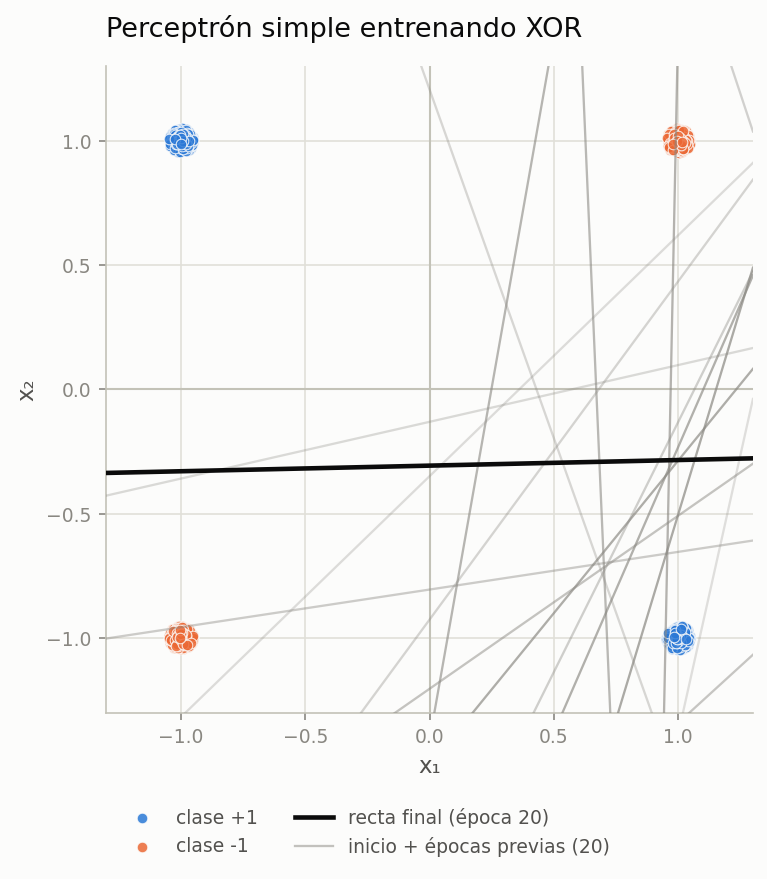

In [5]:
graficar_entrenamiento(
    entradas_xor,
    salidas_deseadas_xor,
    historial_pesos_xor,
    titulo="Perceptrón simple entrenando XOR",
);

### Análisis

Los dos gráficos muestran comportamientos opuestos.

En el **OR** la recta parte de una posición aleatoria y en dos épocas se acomoda dejando el
vértice $(-1,-1)$ de un lado y los otros tres del otro. Hallada esa posición ya no vuelve a
moverse, porque no queda ningún patrón mal clasificado que dispare una corrección.

En el **XOR** la recta nunca se detiene: las veinte posiciones dibujadas la muestran girando
y desplazándose sin encontrar jamás una configuración estable. El entrenamiento agota el
máximo de épocas sin que el criterio `cero_errores` llegue a activarse, y la cantidad de
errores oscila en torno al 42 % de los patrones sin descender.

#### Por qué el XOR no puede resolverse

Los patrones de clase $+1$ ocupan los vértices $(1,-1)$ y $(-1,1)$, mientras que los de clase
$-1$ ocupan $(1,1)$ y $(-1,-1)$. Cada clase está sobre una de las dos **diagonales** del
cuadrado. Una recta divide el plano en dos semiplanos, y no existe manera de dejar una
diagonal completa a cada lado.

Esto puede demostrarse formalmente. Para que un perceptrón resolviera el XOR deberían
cumplirse simultáneamente las cuatro condiciones:

$$\begin{aligned}
(1,\,1) \to -1: & \quad w_1 + w_2 - \theta < 0 \\
(-1,\,-1) \to -1: & \quad -w_1 - w_2 - \theta < 0 \\
(1,\,-1) \to +1: & \quad w_1 - w_2 - \theta \geq 0 \\
(-1,\,1) \to +1: & \quad -w_1 + w_2 - \theta \geq 0
\end{aligned}$$

Sumando miembro a miembro las dos primeras se obtiene $-2\theta < 0$, es decir
$\theta > 0$. Sumando las dos últimas se obtiene $-2\theta \geq 0$, es decir
$\theta \leq 0$. Ambas conclusiones son incompatibles, de modo que **no existe ninguna terna
$(w_1, w_2, \theta)$ que resuelva el problema**.

Obsérvese que en la demostración no intervienen ni la tasa de aprendizaje ni la cantidad de
épocas: la solución sencillamente no existe, y por lo tanto ningún algoritmo ni ningún tiempo
de cómputo pueden encontrarla.

#### Verificación experimental

Se comprobó empíricamente que **ampliar la cantidad de épocas no produce ninguna mejora**: en
corridas de hasta 10 000 épocas la cantidad de errores se mantuvo oscilando en el mismo
rango, con un promedio de 847 errores sobre 2000 patrones en las últimas mil épocas,
prácticamente idéntico al de las primeras.

**Modificar la tasa de aprendizaje tampoco sirve**: con valores entre 0,001 y 1,0 el
resultado siguió ubicándose entre el 26 % y el 51 % de aciertos, sin ninguna tendencia de
mejora. El fracaso no se debe entonces a una convergencia lenta ni a hiperparámetros mal
elegidos.

Vale la pena notar que el acierto obtenido **depende de en qué época se detenga el
entrenamiento**, ya que los pesos nunca se estabilizan. Esa variabilidad es en sí misma
evidencia del problema: no se trata de un modelo que converge a una solución mediocre, sino
de uno que jamás converge.

Un barrido exhaustivo sobre todas las rectas posibles del plano —recorriendo todas las
pendientes y todos los desplazamientos— permite además cuantificar el techo del modelo: la
mejor recta alcanza apenas un **75,4 %** de aciertos. El valor es coherente con la geometría
del problema, ya que una recta puede a lo sumo aislar un vértice y acertar tres de los cuatro
grupos. Resulta interesante que el perceptrón entrenado quede incluso por debajo de ese
techo, cuestión que se retoma en las conclusiones.

La conclusión es que el problema no se resuelve ajustando parámetros sino **cambiando la
arquitectura**: hacen falta varias neuronas, es decir un perceptrón multicapa capaz de
combinar más de una recta para delimitar la región correcta.

---

## Ejercicio 3

> Repita el entrenamiento realizado para el caso del OR, pero entrenando con los archivos
> `OR_50_trn.csv` y `OR_90_trn.csv`, y sus correspondientes `OR_50_tst.csv` y
> `OR_90_tst.csv` para test. Estos datos fueron generados de la misma forma que los usados en
> el primer ejercicio, pero utilizando desviaciones aleatorias de 50 % y 90 %,
> respectivamente. Analice y discuta los resultados.

### Qué se hizo

Se entrenó el mismo perceptrón, con idénticos parámetros y semilla, sobre los tres conjuntos
de datos del problema OR —con desviaciones del 5 %, 50 % y 90 %— y se evaluó cada uno contra
su archivo de prueba correspondiente. Se comparan la cantidad de épocas necesarias, si el
entrenamiento llegó a converger y el porcentaje de aciertos.

In [6]:
conjuntos = [
    ("OR 5%", "OR_trn.csv", "OR_tst.csv"),
    ("OR 50%", "OR_50_trn.csv", "OR_50_tst.csv"),
    ("OR 90%", "OR_90_trn.csv", "OR_90_tst.csv"),
]

resultados = []

for nombre, archivo_entrenamiento, archivo_prueba in conjuntos:
    entradas, salidas_deseadas = cargar_patrones(DIRECTORIO_DATASET / archivo_entrenamiento)
    entradas_prueba, salidas_deseadas_prueba = cargar_patrones(DIRECTORIO_DATASET / archivo_prueba)

    perceptron = Perceptron(
        cantidad_entradas=entradas.shape[1],
        tasa_aprendizaje=tasa_aprendizaje,
        semilla=semilla,
    )

    errores_por_epoca, historial_pesos = perceptron.entrenar(
        entradas,
        salidas_deseadas,
        maximo_epocas=maximo_epocas,
        criterio_de_corte=criterio_de_corte,
    )

    porcentaje_aciertos, cantidad_errores_prueba = perceptron.probar(
        entradas_prueba, salidas_deseadas_prueba
    )

    resultados.append({
        "nombre": nombre,
        "entradas": entradas,
        "salidas_deseadas": salidas_deseadas,
        "pesos": perceptron.pesos,
        "umbral": perceptron.umbral,
        "errores": errores_por_epoca,
        "epocas": len(errores_por_epoca),
        "errores_ultima_epoca": errores_por_epoca[-1],
        "cantidad_patrones": len(salidas_deseadas),
        "porcentaje_aciertos": porcentaje_aciertos,
        "convergio": errores_por_epoca[-1] == 0,
    })

print(f"{'conjunto':<10}{'épocas':>8}{'convergió':>12}{'err. últ. época':>18}{'test':>10}")
for resultado in resultados:
    convergio = "sí" if resultado["convergio"] else "no"
    errores = f"{resultado['errores_ultima_epoca']}/{resultado['cantidad_patrones']}"
    print(f"{resultado['nombre']:<10}{resultado['epocas']:>8}{convergio:>12}"
          f"{errores:>18}{resultado['porcentaje_aciertos']:>9.2f}%")

conjunto    épocas   convergió   err. últ. época      test
OR 5%            2          sí            0/2000   100.00%
OR 50%           2          sí            0/1000   100.00%
OR 90%         100          no           58/1000    93.00%


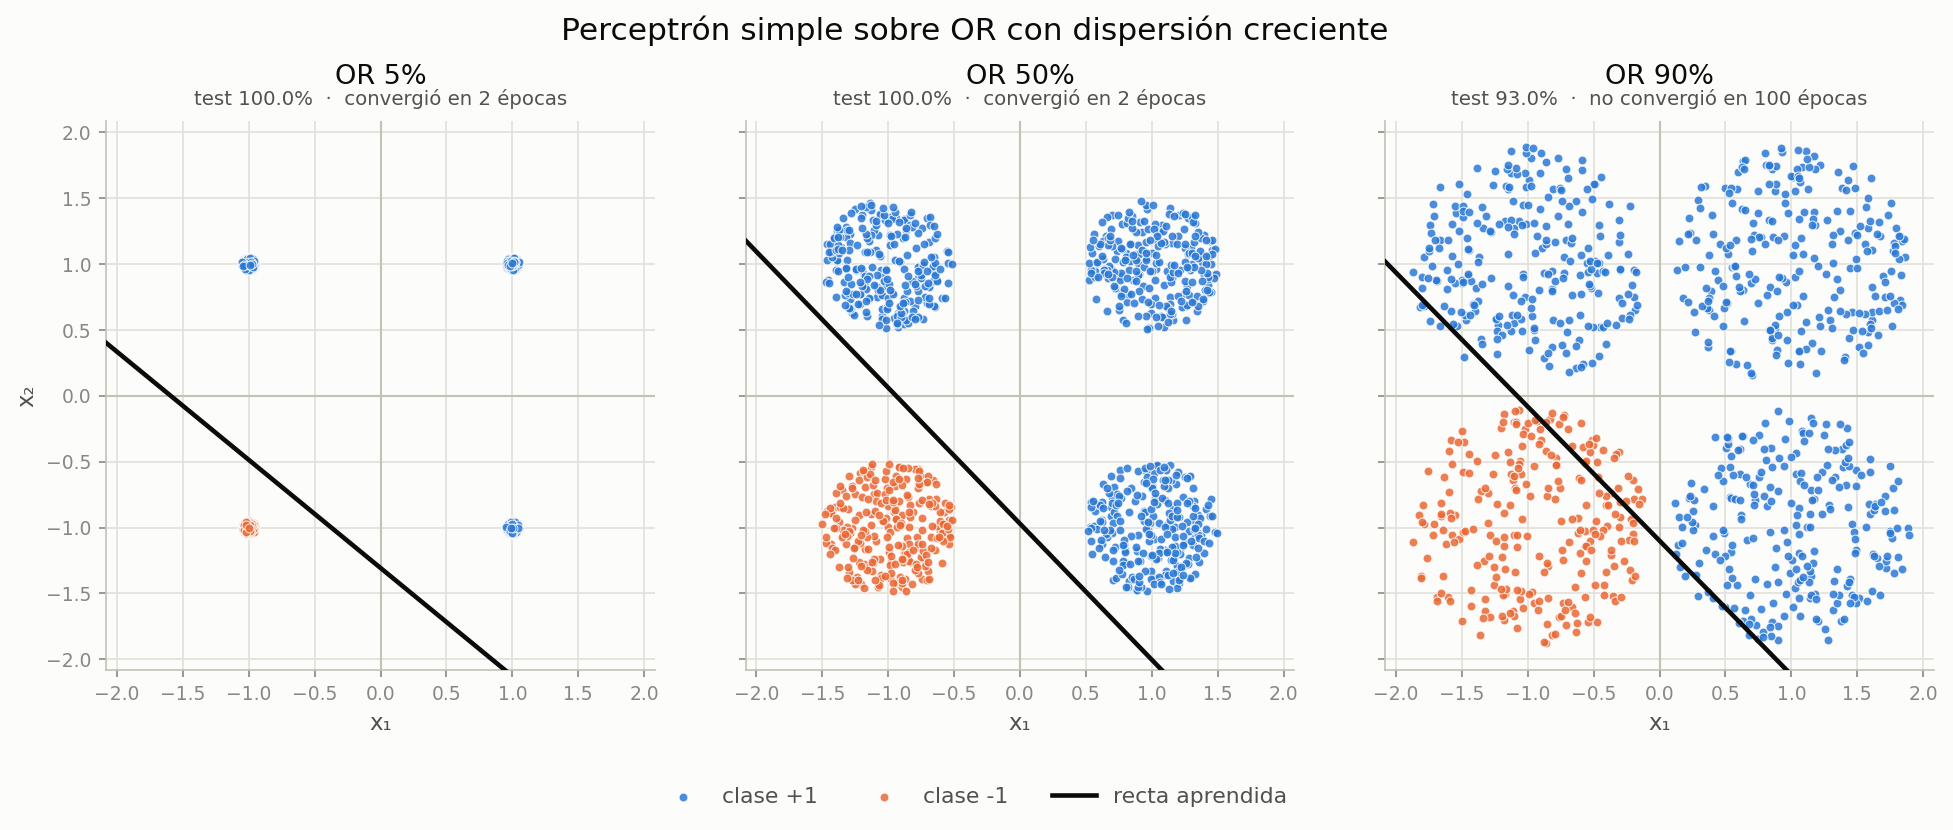

In [7]:
graficar_comparacion_dispersiones(resultados);

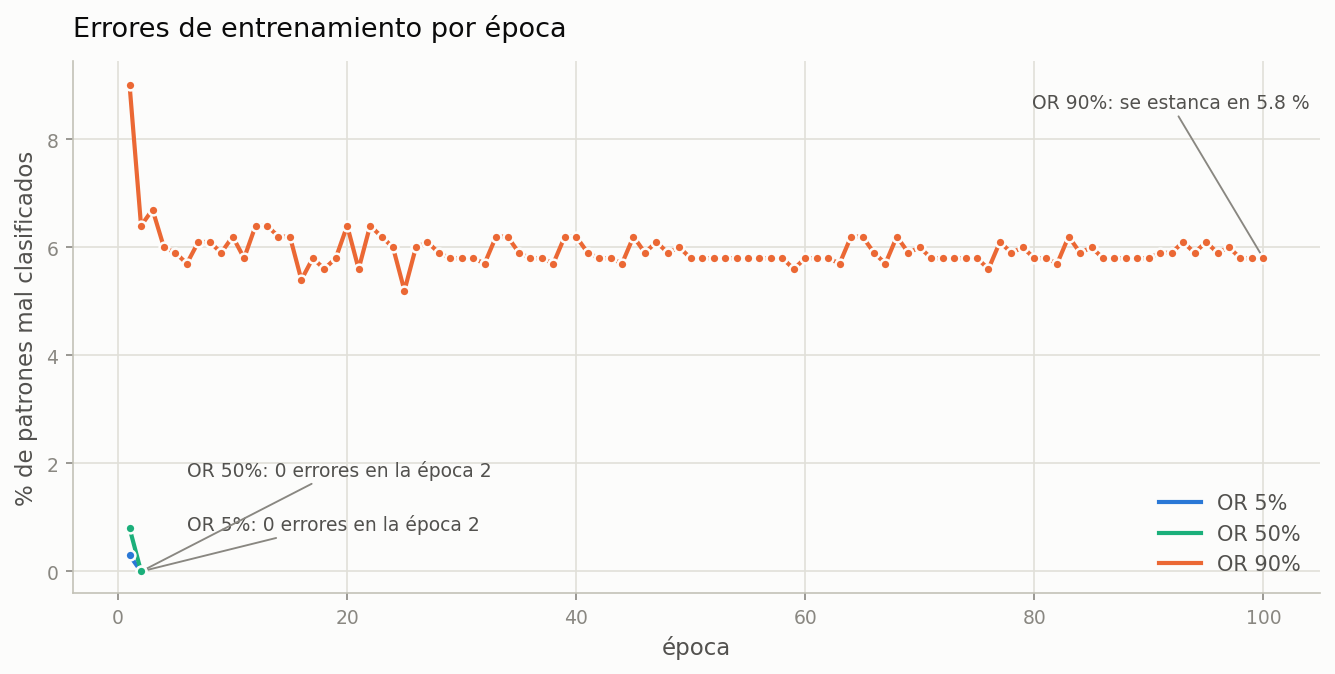

In [8]:
graficar_errores_por_epoca(
    [
        {
            "etiqueta": resultado["nombre"],
            "errores": resultado["errores"],
            "cantidad_patrones": resultado["cantidad_patrones"],
        }
        for resultado in resultados
    ],
    titulo="Errores de entrenamiento por época",
);

### Análisis

El resultado más llamativo es que **una desviación del 50 % no afecta en absoluto al
perceptrón**. Las nubes de patrones crecen enormemente respecto del caso original —dejan de
ser puntos concentrados para convertirse en discos amplios— y sin embargo el entrenamiento
converge en las mismas 2 épocas y alcanza el mismo 100 % de aciertos en prueba.

La conclusión no es evidente a primera vista: **lo que limita al perceptrón no es la
dispersión de los datos en sí, sino que las clases lleguen a solaparse**. Mientras exista
algún corredor libre entre ambas clases, por estrecho que sea, la recta lo encuentra.

Con una desviación del 90 % ese corredor desaparece. Proyectando los patrones sobre la
diagonal $x_1 + x_2$, que es la dirección natural de separación del OR, se observa el punto
de quiebre con claridad:

| conjunto | rango clase $-1$ | rango clase $+1$ | situación |
|---|---|---|---|
| OR 50 % | $[-1{,}91;\; -0{,}92]$ | $[-0{,}49;\; 1{,}91]$ | separadas por 0,42 |
| OR 90 % | $[-2{,}30;\; -0{,}52]$ | $[-0{,}87;\; 2{,}30]$ | **se solapan en 0,35** |

En el conjunto con 90 % de desviación hay 69 patrones de clase $+1$ dentro del rango ocupado
por los de clase $-1$, y 45 patrones de clase $-1$ dentro del rango de los $+1$: en total 114
patrones invadiendo territorio ajeno, que ninguna recta puede clasificar correctamente. Un
barrido exhaustivo sobre todas las rectas posibles confirma que el techo alcanzable es del
**96,2 %**, esto es 38 errores inevitables sobre 1000 patrones.

Coherentemente, el entrenamiento sobre `OR_90` **agota las 100 épocas sin converger**, y el
gráfico de errores por época muestra una curva que se estabiliza alrededor del 6 % sin
descender más, en contraste con las otras dos, que caen a cero de inmediato. El desempeño en
prueba se mantiene no obstante elevado, en torno al 93 %: el modelo es incapaz de clasificar
perfectamente, pero la recta que encuentra sigue siendo razonable.

#### Comparación con el XOR

Conviene distinguir este caso del XOR del Ejercicio 2, porque si bien en ambos el
entrenamiento no converge, las causas son de naturaleza distinta:

| | XOR | OR 90 % |
|---|---|---|
| causa | limitación **estructural** de representación | **solapamiento** de clases por ruido |
| calidad de los datos | perfecta, sin ruido | muy dispersa |
| techo alcanzable | 75,4 % | 96,2 % |
| cómo se resuelve | cambiando la arquitectura | mejorando los datos |

En el XOR la solución no existe, y ningún dato de mejor calidad la haría aparecer. En
`OR_90` la solución casi existe, y de hecho el mismo modelo funciona perfectamente sobre los
mismos datos con menor dispersión.

Por último, se observa nuevamente que el perceptrón termina con más errores que el mínimo
teórico alcanzable, cuestión que se aborda en las conclusiones.

---

## Conclusiones generales

**El perceptrón simple resuelve exactamente los problemas linealmente separables, y sólo
ésos.** Su frontera de decisión es una recta —un hiperplano en el caso general— y en eso
consisten tanto su capacidad como su límite. El problema OR, con dispersiones del 5 % y del
50 %, se resuelve con 100 % de aciertos en apenas dos épocas.

**El criterio de finalización distingue los dos escenarios posibles.** Cuando el problema es
separable, el criterio de cero errores se activa rápidamente y el máximo de épocas nunca
entra en juego, en línea con el teorema de convergencia del perceptrón, que garantiza hallar
una solución en un número finito de pasos. Cuando no lo es, ese criterio no se activa jamás y
el máximo de épocas pasa a ser el único corte efectivo. De allí que la guía pidiera que ambos
fueran configurables.

**Ni la tasa de aprendizaje ni la cantidad de épocas compensan una limitación estructural.**
Se verificó experimentalmente que extender el entrenamiento a 10 000 épocas o recorrer tasas
de aprendizaje entre 0,001 y 1,0 no mejora en absoluto el resultado sobre el XOR. En los
problemas separables, además, la tasa de aprendizaje resultó prácticamente irrelevante, como
consecuencia de que la función signo es invariante a escala y por lo tanto la magnitud de los
pesos no altera la posición de la frontera de decisión.

**Los dos modos de fallo son distintos y conviene no confundirlos.** El XOR falla por
incapacidad de representación —la solución no existe, y se demuestra formalmente por
contradicción—, mientras que `OR_90` falla por solapamiento de clases —la solución óptima
existe pero no es perfecta, y el modelo se aproxima razonablemente a ella—. El primer caso
exige cambiar de arquitectura; el segundo, mejorar la calidad de los datos.

**La regla de aprendizaje del perceptrón no es un algoritmo de optimización.** Corrige el
patrón que tiene delante sin considerar el error global, de modo que ante datos no separables
no converge ni se detiene en la mejor solución disponible, sino que oscila indefinidamente.
Esto explica que tanto en el XOR como en `OR_90` el modelo termine por debajo del techo
teórico calculado. Una solución clásica a este comportamiento es el *pocket algorithm*, que
consiste en conservar aparte los mejores pesos observados a lo largo del entrenamiento y
devolver ésos al finalizar, en lugar de los correspondientes a la última iteración. Más
fundamentalmente, esta limitación motiva el paso a reglas de aprendizaje basadas en el
descenso por gradiente de una función de error, tema con el que continúa la asignatura.